In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spopt
import numpy.ma as ma
from tqdm import tqdm
import pandas as pd
import glob, os
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Circle

import sys
#Need this command for the _merge function for recursion
sys.setrecursionlimit(10**5)

In [35]:
def nrt_hours(activity_phase_1=False, activity_phase_2=False):

    #Opening the most recent master_df, dont forget to pull the git repo
    master_df = pd.read_csv("/home/omar/git/logs/master_df.csv", sep=",", header=0, index_col=0, \
                            na_values='NA', engine='python')

    df = master_df[(master_df["Source_Name"].isin(["R240114"])) &
                   (master_df["Telescope"].isin(["Nancay"]))].copy()
    df = df[df["Central_freq_(MHz)"] < 2000]  # keep only L-band and below

    df = df.sort_values(by="Obs_Date_String")
    
    #Adding in the observed_hours per row
    df["observed_hours"] = (df["MJD_end_time"] - df["MJD_start_time"]) * 24

    if activity_phase_1:
        bound_l, bound_r = 60337, 60552
        #bound_l, bound_r = 60355, 60552
        #bound_l, bound_r = 60346, 60723
        print(f"!!Using Activity phase!! begin: {bound_l} | end: {bound_r}")
        df = df[(df['MJD_start_time'] > bound_l) & (df['MJD_end_time'] < bound_r)]
        display(df)
    elif activity_phase_2:
        bound_l, bound_r = 60337, 60724
        #bound_l, bound_r = 60355, 60552
        #bound_l, bound_r = 60346, 60723
        print(f"!!Using Activity phase!! begin: {bound_l} | end: {bound_r}")
        df = df[(df['MJD_start_time'] > bound_l) & (df['MJD_end_time'] < bound_r)]   
        display(df)
    #display(df)
    total_hours = sum(df["observed_hours"].values)
    print(f"total hours NRT: {total_hours:.2f} h")
    
    return

nrt_hours(activity_phase_1=True)
nrt_hours(activity_phase_2=True)

!!Using Activity phase!! begin: 60337 | end: 60552


,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),...,bytes_in_file_header,MJD_end_time,complete_filename,Are_bytes_signed?,Polarization_order,Backend,Starting_subint,Subints_per_file,Source_Name_nancay,observed_hours
122269,nuppi_60344_2127+0421_292167,no001,Nancay,R240114,2024-02-04T11:51:24,60344.494028,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.495417,lilo_1x1_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122270,nuppi_60344_2127+0421_292167,no002,Nancay,R240114,2024-02-04T11:53:24,60344.495417,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.496806,lilo_1x2_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122271,nuppi_60344_2127+0421_292167,no003,Nancay,R240114,2024-02-04T11:55:24,60344.496806,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.498194,lilo_1x3_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122272,nuppi_60344_2127+0421_292167,no004,Nancay,R240114,2024-02-04T11:57:24,60344.498194,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.499583,lilo_1x4_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122273,nuppi_60344_2127+0421_292167,no005,Nancay,R240114,2024-02-04T11:59:24,60344.499583,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.500972,lilo_1x5_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156710,nuppi_60547_2127+0421_297896,no0025,Nancay,R240114,2024-08-25T23:25:07.40429,60547.975780,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60547.977169,lilo_5x1_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
156711,nuppi_60547_2127+0421_297896,no0026,Nancay,R240114,2024-08-25T23:27:07.40429,60547.977169,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60547.978558,lilo_5x2_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
156712,nuppi_60547_2127+0421_297896,no0027,Nancay,R240114,2024-08-25T23:29:07.40429,60547.978558,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60547.979947,lilo_5x3_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
156713,nuppi_60547_2127+0421_297896,no0028,Nancay,R240114,2024-08-25T23:31:07.40429,60547.979947,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60547.981336,lilo_5x4_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333


total hours NRT: 39.70 h
!!Using Activity phase!! begin: 60337 | end: 60724


,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),...,bytes_in_file_header,MJD_end_time,complete_filename,Are_bytes_signed?,Polarization_order,Backend,Starting_subint,Subints_per_file,Source_Name_nancay,observed_hours
122269,nuppi_60344_2127+0421_292167,no001,Nancay,R240114,2024-02-04T11:51:24,60344.494028,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.495417,lilo_1x1_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122270,nuppi_60344_2127+0421_292167,no002,Nancay,R240114,2024-02-04T11:53:24,60344.495417,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.496806,lilo_1x2_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122271,nuppi_60344_2127+0421_292167,no003,Nancay,R240114,2024-02-04T11:55:24,60344.496806,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.498194,lilo_1x3_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122272,nuppi_60344_2127+0421_292167,no004,Nancay,R240114,2024-02-04T11:57:24,60344.498194,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.499583,lilo_1x4_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
122273,nuppi_60344_2127+0421_292167,no005,Nancay,R240114,2024-02-04T11:59:24,60344.499583,21:27:39.0000,321.9125,04:20:60.0000,4.350000,...,350.0,60344.500972,lilo_1x5_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190809,nuppi_60722_2127+0421_301887,no0030,Nancay,R240114,2025-02-16T11:57:21.4043,60722.498164,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60722.498984,lilo_5x6_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.019681
190810,nuppi_60722_2127+0421_301887,no0031,Nancay,R240114,2025-02-16T11:58:32.2554,60722.498984,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60722.500373,lilo_6x1_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
190811,nuppi_60722_2127+0421_301887,no0032,Nancay,R240114,2025-02-16T12:00:32.2554,60722.500373,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60722.501762,lilo_6x2_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333
190812,nuppi_60722_2127+0421_301887,no0033,Nancay,R240114,2025-02-16T12:02:32.2554,60722.501762,21:27:39.0000,321.9125,04:19:46.0000,4.329444,...,350.0,60722.503151,lilo_6x3_8bit.txt,False,NaN,NaN,NaN,NaN,2127+0421,0.033333


total hours NRT: 55.99 h


In [43]:
def master_opener(dwi_import=True):
    """
    Opens and processes the master DataFrame from a CSV file, performs data cleaning and filtering, 
    and returns a subset of the data relevant to a specific source and telescopes.

    The function performs the following:
    - Loads the most recent `master_df` from a CSV file.
    - Adds a column for observed hours, calculated from MJD start and end times.
    - Sorts the DataFrame by observation date.
    - Filters rows for the source R147 and aliases (FRB20240114A,R240121,R240114) and specific telescopes, excluding 'Nancay'.
    - Outputs the unique set of telescope names and central frequencies for the filtered data.

    Returns:
        pd.DataFrame: A DataFrame (`df`) filtered for the specified source and telescopes.
    """
    #Opening the most recent master_df, dont forget to pull the git repo
    master_df = pd.read_csv("/home/omar/git/logs/master_df.csv", sep=",", header=0, index_col=0, \
                            na_values='NA', engine='python')

    # Filter for the desired source and telescopes
    mask = (
        (master_df["Source_Name"].isin(["R240121", "R240114", "FRB20240114A"])) &
        (master_df["Telescope"].isin(["wb", "tr", "stk", "o8", "Nancay"])) &
        (
            (master_df["Telescope"] != "Nancay") |
            (
                (master_df["MJD_start_time"] < 60723) &
                (master_df["Central_freq_(MHz)"] < 2000)
            )
        )
    )
    df = master_df[mask].copy()
    
    if dwi_import:
        # Import the dwingeloo database 
        dwi_df = pd.read_csv("DWi_R147_322_scans_dwi_2026_V1_jan26.csv", sep=",", index_col=0, na_values='NA', engine='python')
        df_merged = pd.concat([df, dwi_df], ignore_index=True, sort=False)
    else:
        df_merged = df

    #April 1 cutoff to get 800 days of exposure (61143)
    df_merged = df_merged[df_merged["MJD_start_time"] < 61144]
    
    # condition for rows to drop
    #Here we remove the observations were we were not on source, these are tied to RA of 323.514350
    mask = df_merged["RA_J2000_(deg)"] == 323.514350
    # get the unique scan_names that will be dropped
    dropped_scan_names = set(df_merged.loc[mask, "scan_name"])
    # drop the rows
    df_merged = df_merged.loc[~mask].reset_index(drop=True)
    # print the result
    print(f"observations dropped that were not on source: {dropped_scan_names}")

    #Adding in the observed_hours per row
    df_merged["observed_hours"] = (df_merged["MJD_end_time"] - df_merged["MJD_start_time"]) * 24
    
    #Sort just because 
    df_merged = df_merged.sort_values(by="Obs_Date_String")

    #e-EVN observations, couple lines of Onsala made it in the db, need to remove that
    df_merged = df_merged[(df_merged["scan_name"] != "rk002")]
    
    display(df_merged)
    
    freq_tel = df_merged.groupby("Central_freq_(MHz)")["Telescope"].unique()
    print(freq_tel)
    
    return df_merged

df_r147 = master_opener()

observations dropped that were not on source: {'rn1l01', 'pcn237', 'rn1l02', 'pcn238', 'pcn235', 'pcn236'}


,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),...,bytes_in_file_header,MJD_end_time,complete_filename,Are_bytes_signed?,Polarization_order,Backend,Starting_subint,Subints_per_file,Source_Name_nancay,observed_hours
0,pcn239,no0001,wb,R240121,2024-01-29T13:00:01,60338.541678,21:27:39.8880,321.916200,04:21:00.3600,4.350100,...,295.0,60338.552083,pcn239_wb_no0001_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249719
1,pcn239,no0002,wb,R240121,2024-01-29T13:15:15,60338.552257,21:27:39.8880,321.916200,04:21:00.3600,4.350100,...,295.0,60338.562639,pcn239_wb_no0002_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
2,pcn239,no0003,wb,R240121,2024-01-29T13:30:27,60338.562813,21:27:39.8880,321.916200,04:21:00.3600,4.350100,...,295.0,60338.573194,pcn239_wb_no0003_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
3,pcn239,no0004,wb,R240121,2024-01-29T13:45:39,60338.573368,21:27:39.8880,321.916200,04:21:00.3600,4.350100,...,295.0,60338.583750,pcn239_wb_no0004_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
4,pcn239,no0005,wb,R240121,2024-01-29T14:00:51,60338.583924,21:27:39.8880,321.916200,04:21:00.3600,4.350100,...,295.0,60338.594305,pcn239_wb_no0005_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,p79075,no0017,wb,R240114,2026-04-13T08:53:57,61143.370799,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,61143.381180,p79075_wb_no0017_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249146
14475,p79075,no0018,wb,R240114,2026-04-13T09:09:09,61143.381354,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,61143.391723,p79075_wb_no0018_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.248855
14476,p79075,no0019,wb,R240114,2026-04-13T09:24:21,61143.391910,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,61143.402291,p79075_wb_no0019_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249146
14477,p79075,no0020,wb,R240114,2026-04-13T09:39:33,61143.402465,21:27:39.8354,321.915981,04:19:45.6344,4.329343,...,295.0,61143.412846,p79075_wb_no0020_IFall_vdif_pol2.txt,False,NaN,NaN,NaN,NaN,NaN,0.249146


Central_freq_(MHz)
332.000000         [wb]
410.062500         [dw]
1250.078125        [dw]
1250.156250        [dw]
1271.000000        [wb]
1381.464844       [stk]
1414.000000        [tr]
1418.000000        [tr]
1424.000000        [o8]
1444.000000        [tr]
1469.000000        [tr]
1484.000000    [Nancay]
4708.000000        [tr]
Name: Telescope, dtype: object


In [44]:
#dictionary with frequency setups
def freq_dict_maker():
    
    #acces with: freq_dict[332]
    #12 setupts for R147
    freq_dict = {
        332 : "P", #wb
        1271 : "L18", #wb
        1381.46484375 : "L13", #st
        1424 : "L1", #o8
        4708 : "C4", #tr
        1414 : "L15-old", #tr
        1444 : "L15", #tr
        1418 : "L15-2", #tr
        1469 : "L15-3", #tr
        #1424 : "L15-3", #tr      
        1250.15625 : "L19_1", #dw
        1250.078125 : "L19_2", #dw
        410.0625 : "P_2", #dw
        # 1350.15625 : "L20_2",
        # 1350.078125 : "L20_2",
        # 1300.15625 : "L21",
        1484 : "nrt-l",
        2509 : "nrt-s-1",
        2539 : "nrt-s-2"
    
    }
    
    return freq_dict

In [45]:
def _merge(head, tail):
    if not tail:
        return head

    a, b = head[-1]
    x, y = tail[0]

    if b >= x:
        # Merge overlapping intervals
        head[-1] = (a, max(b, y))
    else:
        # No overlap, append the next interval
        head.append(tail[0])

    return _merge(head, tail[1:])


def merge_intervals(intervals):
    if len(intervals) <= 1:
        return intervals
    
    # Sort by the start time of intervals
    intervals = sorted(intervals, key=lambda x: x[0])

    # Merge intervals using recursion
    return _merge([intervals[0]], intervals[1:])

def get_overlap_times(df, start_col="MJD_start_time", end_col="MJD_end_time"):
    """
    Get the non-overlapping intervals from start and end times in the DataFrame.
    
    Args:
        df (pd.DataFrame): The DataFrame containing start and end times.
        start_col (str): Column name for start times.
        end_col (str): Column name for end times.
        
    Returns:
        list of tuple: Non-overlapping time intervals.
    """
    # Extract start and end times as arrays
    start = df[start_col].values
    end = df[end_col].values
    
    # Validate time intervals
    if np.any(start >= end):
        print("WARNING: Start time should not exceed end time in any row.")
    
    # Create tuple pairs of (start, end) times
    time_intervals = list(zip(start, end))
    
    # Merge overlapping intervals
    return merge_intervals(time_intervals)

def calc_overlap_times(times, unit="days"):
    """
    Calculate the total time for non-overlapping intervals.
    Times is a list of tuple pairs, e.g.:
    [(1, 3), (5.5, 6.0)]
    Will return the sum of the differences of the pairs:
    [(1, 3), (5.5, 6.0)] --> (3-1) + (6.0-5.5) = 2 + 0.5 = 2.5 
    Args:
        times (list of tuple): List of time intervals as (start, end) pairs.
        unit (str): Time unit to display the result (default is 'days').
    
    Returns:
        float: Total time in the given unit.
    """
    total_time = sum(e - s for s, e in times)
    
    # Print the result
    if unit == "days":
        print(f"The total non-overlapping observing time is {total_time:.2f} days or {(total_time * 24):.2f} hours.")
    else:
        print(f"The total non-overlapping observing time is {total_time:.2f} {unit}.")
    
    return total_time

In [50]:
def hours_calc(df_source, total_time=False, activity_phase=False, activity_phase_2=False, save_bool=False):
    """
    Calculates the observation time per telescope and frequency band from the source DataFrame.
    
    Args:
        df_source (pd.DataFrame): Source DataFrame with observation details.
        total_time (bool): If True, calculates total observation time, including overlaps.
        activity_phase (bool): If True, limits data to the activity phase time window.
        save_bool (bool): If True, saves the filtered DataFrame as a CSV file.
    
    Returns:
        pd.DataFrame: The (potentially filtered) DataFrame.
    """
    
    # Call the frequency dictionary
    freq_dict = freq_dict_maker()

    # Calculate total observation time in seconds
    df_source["total_obs_time_s"] = (df_source["MJD_end_time"] - df_source["MJD_start_time"]) * 24 * 3600
    
    # Print observing frequencies
    print(set(df_source['Central_freq_(MHz)'].values))
    
    # Limit to activity phase 
    # The first burst was detected by XXXXX
    # The last burst was detected by XXXXX
    if activity_phase:
        bound_l, bound_r = 60337, 60552
        #bound_l, bound_r = 60355, 60552
        #bound_l, bound_r = 60362, 60412
        #bound_l, bound_r = 60346, 60723
        print(f"!!Using Activity phase!! begin: {bound_l} | end: {bound_r}")
        df_source = df_source[(df_source['MJD_start_time'] > bound_l) & (df_source['MJD_end_time'] < bound_r)]

    elif activity_phase_2:
        bound_l, bound_r = 60337, 60723
        print(f"!!Using Activity phase!! begin: {bound_l} | end: {bound_r}")
        df_source = df_source[(df_source['MJD_start_time'] > bound_l) & (df_source['MJD_end_time'] < bound_r)]
        
    # Calculate observing hours for each telescope
    telescopes = ['wb', 'tr', 'stk', 'o8', 'dw', 'Nancay']
    for telescope in telescopes:
        obs_hours = df_source[df_source["Telescope"] == telescope]["total_obs_time_s"].sum() / 3600
        print(f"total obs {telescope}: {obs_hours:.2f} h")
            
    # Total observing time
    total_obs = df_source["total_obs_time_s"].sum() / 3600
    print(f"total observing time: {total_obs:.2f} h")
    print("--------------------")

    # Frequency-based calculations (P-band, C-band, L-band)
    band_freqs = {'P-band': [332.0, 410.0625], 'C-band': [4708.0], 'S-band': [2509.0, 2539.0]}

    for band, freqs in band_freqs.items():
        print(f"-{band}-")
        df_band = df_source[df_source["Central_freq_(MHz)"].isin([freqs] if isinstance(freqs, float) else freqs)]
        times_band = get_overlap_times(df_band)
        calc_overlap_times(times_band)
    
    print("-L band (without NRT L-band)-")
    df_lband = df_source[~df_source["Central_freq_(MHz)"].isin([332.0, 4708.0, 410.0625, 2509.0, 2539.0, 1484.0])]
    times_lband = get_overlap_times(df_lband)
    calc_overlap_times(times_lband)

    print("-L band (with NRT L-band)-")
    df_lband = df_source[~df_source["Central_freq_(MHz)"].isin([332.0, 4708.0, 410.0625, 2509.0, 2539.0])]
    times_lband = get_overlap_times(df_lband)
    calc_overlap_times(times_lband)
    
    # Calculate total unique observation time if requested
    if total_time:
        print("--------------------")
        times_total = get_overlap_times(df_source)
        calc_overlap_times(times_total)
        print("--------------------")
    
    #Counters for observing time
    total_h_obs = 0
    total_h_obs_lband = 0

    # Summarize observing time per frequency setup
    total_h_obs = 0
    total_h_obs_lband = 0
    for freq, freq_label in freq_dict.items():
        
        df_freq_setup = df_source[df_source['Central_freq_(MHz)'] == freq]
        
        obs_time_h = df_freq_setup["total_obs_time_s"].sum() / 3600
        
        part_telescope = set(df_freq_setup["Telescope"])
        
        print(f"{freq_label}: time = {obs_time_h:.2f} h -- central_freq {freq} -- {part_telescope}")
        
        total_h_obs += obs_time_h
        
        if freq_label.startswith("L"):
            total_h_obs_lband += obs_time_h
    
    print(f"Total observing on L-band: {total_h_obs_lband:.2f}")
    print(f"as a double check, the total is over the freq setup is: {total_h_obs:.2f}")
    print("--------------------")
    
    ##Ran on 14-April 2026 --- for end date 07 april
    if save_bool == True:
        display(df_source)
        df_source = df_source.sort_values(by=['MJD_start_time'])
        csv_obs = "../databases//r147_fullcampaign_V3.csv"
        df_source.to_csv(csv_obs, sep=",", header=True, index=True, na_rep='NA')
        print("campaign saved")
        
    return df_source

In [51]:
df_campaign = hours_calc(df_r147, total_time=True, activity_phase=False, save_bool=False)

{1250.078125, 1250.15625, 4708.0, 1381.46484375, 1414.0, 1444.0, 1418.0, 1484.0, 332.0, 1424.0, 1271.0, 410.0625, 1469.0}
total obs wb: 2216.56 h
total obs tr: 517.35 h
total obs stk: 1228.15 h
total obs o8: 167.47 h
total obs dw: 48.07 h
total obs Nancay: 55.99 h
total observing time: 4233.58 h
--------------------
-P-band-
The total non-overlapping observing time is 28.89 days or 693.27 hours.
-C-band-
The total non-overlapping observing time is 2.67 days or 64.18 hours.
-S-band-
The total non-overlapping observing time is 0.00 days or 0.00 hours.
-L band (without NRT L-band)-
The total non-overlapping observing time is 111.17 days or 2668.09 hours.
-L band (with NRT L-band)-
The total non-overlapping observing time is 112.01 days or 2688.24 hours.
--------------------
The total non-overlapping observing time is 119.23 days or 2861.53 hours.
--------------------
P: time = 676.72 h -- central_freq 332 -- {'wb'}
L18: time = 1539.85 h -- central_freq 1271 -- {'wb'}
L13: time = 1228.15 h

In [48]:
df_campaign = hours_calc(df_r147, total_time=True, activity_phase=True, save_bool=False)

{1250.078125, 1250.15625, 4708.0, 1381.46484375, 1414.0, 1444.0, 1418.0, 1484.0, 332.0, 1424.0, 1271.0, 410.0625, 1469.0}
!!Using Activity phase!! begin: 60337 | end: 60552
total obs wb: 1021.73 h
total obs tr: 186.92 h
total obs stk: 1060.49 h
total obs o8: 160.25 h
total obs dw: 25.98 h
total obs Nancay: 39.70 h
total observing time: 2495.06 h
--------------------
-P-band-
The total non-overlapping observing time is 26.22 days or 629.36 hours.
-C-band-
The total non-overlapping observing time is 2.67 days or 64.18 hours.
-S-band-
The total non-overlapping observing time is 0.00 days or 0.00 hours.
-L band (without NRT L-band)-
The total non-overlapping observing time is 52.24 days or 1253.77 hours.
--------------------
The total non-overlapping observing time is 58.24 days or 1397.68 hours.
--------------------
P: time = 624.40 h -- central_freq 332 -- {'wb'}
L18: time = 397.33 h -- central_freq 1271 -- {'wb'}
L13: time = 1060.49 h -- central_freq 1381.46484375 -- {'stk'}
L1: time = 

In [49]:
df_campaign = hours_calc(df_r147, total_time=True, activity_phase_2=True, save_bool=False)

{1250.078125, 1250.15625, 4708.0, 1381.46484375, 1414.0, 1444.0, 1418.0, 1484.0, 332.0, 1424.0, 1271.0, 410.0625, 1469.0}
!!Using Activity phase!! begin: 60337 | end: 60723
total obs wb: 1508.70 h
total obs tr: 346.02 h
total obs stk: 1133.52 h
total obs o8: 167.47 h
total obs dw: 48.07 h
total obs Nancay: 55.99 h
total observing time: 3259.76 h
--------------------
-P-band-
The total non-overlapping observing time is 28.55 days or 685.31 hours.
-C-band-
The total non-overlapping observing time is 2.67 days or 64.18 hours.
-S-band-
The total non-overlapping observing time is 0.00 days or 0.00 hours.
-L band (without NRT L-band)-
The total non-overlapping observing time is 76.08 days or 1826.00 hours.
--------------------
The total non-overlapping observing time is 83.86 days or 2012.68 hours.
--------------------
P: time = 668.75 h -- central_freq 332 -- {'wb'}
L18: time = 839.95 h -- central_freq 1271 -- {'wb'}
L13: time = 1133.52 h -- central_freq 1381.46484375 -- {'stk'}
L1: time = 

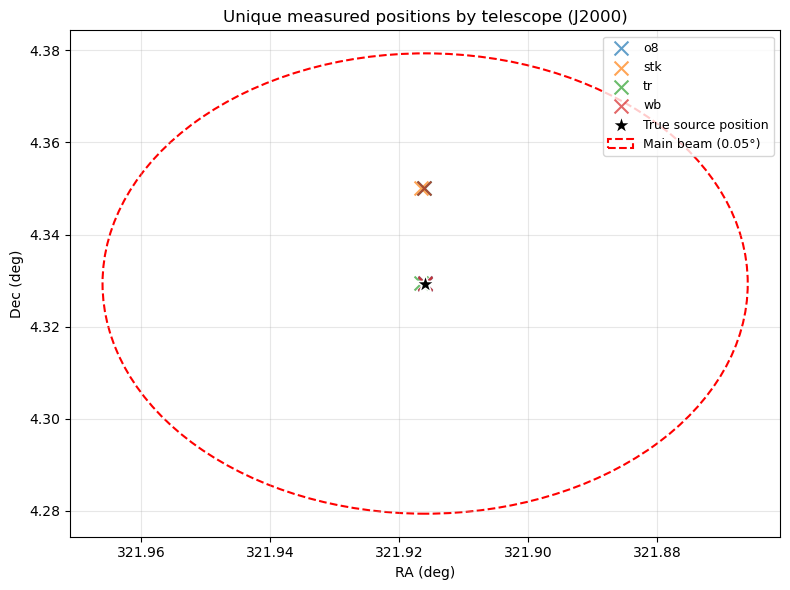

In [10]:
def plot_unique_positions_with_beam(df, beam_radius_deg=0.5):
    """
    Plot unique RA/Dec positions from a DataFrame, grouped by Telescope,
    mark the true source position, and draw a circular main beam.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: "RA_J2000_(deg)", "Dec_J2000_(deg)", "Telescope".
    beam_radius_deg : float
        Radius of the main beam in degrees. Default is 0.5 deg (L-band).
    Made with GPT, but checked
    """
    # Extract unique RA/Dec/Telescope combinations
    # Exclude telescope "dw" and get unique RA/Dec/Telescope combinations
    unique_positions = (
        df[df["Telescope"] != "dw"]
        [["RA_J2000_(deg)", "Dec_J2000_(deg)", "Telescope"]]
        .drop_duplicates()
    )

    true_coord = SkyCoord("21h27m39.835s", "+04d19m45.668s", frame="icrs")
    true_ra_deg = true_coord.ra.deg
    true_dec_deg = true_coord.dec.deg

    # Plot setup
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot unique positions per telescope
    for telescope, subdf in unique_positions.groupby("Telescope"):
        ax.scatter(subdf["RA_J2000_(deg)"], subdf["Dec_J2000_(deg)"],marker="x",s=100,label=telescope,alpha=0.7)

    # Plot true source location
    ax.scatter(true_ra_deg,true_dec_deg,marker="*",s=200,color="black",edgecolor="white",
               linewidth=1.2,label="True source position",zorder=10)

    # Draw main beam circle
    beam = Circle((true_ra_deg,true_dec_deg),radius=beam_radius_deg,edgecolor="red",
                  facecolor="none",linestyle="--",linewidth=1.5,
                  label=f"Main beam ({beam_radius_deg}°)")
    ax.add_patch(beam)

    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title("Unique measured positions by telescope (J2000)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

    plt.tight_layout()
    plt.show()


plot_unique_positions_with_beam(df=df_r147, beam_radius_deg=0.05)

In [54]:
def unique_time_per_mjd_day(df_source, lband_min=1000, lband_max=2000,
                             start_col="MJD_start_time", end_col="MJD_end_time",
                             tel_col="Telescope", freq_col="Central_freq_(MHz)"):
    """
    THIS FUNCTION WAS COMPLETELY WRITTEN BY AI agent CLAUDE
    But tested and verified as much as I could by me, Omar. 
    
    Calculates unique observing time per MJD day, both per-telescope and combined
    (L-band only: 1000-2000 MHz). Scans straddling MJD day boundaries are split
    before any union logic is applied.

    Args:
        df_source (pd.DataFrame): Observation DataFrame.
        lband_min (float): Lower frequency bound for combined calculation (MHz).
        lband_max (float): Upper frequency bound for combined calculation (MHz).
        start_col (str): Column name for MJD start times.
        end_col (str): Column name for MJD end times.
        tel_col (str): Column name for telescope identifier.
        freq_col (str): Column name for central frequency.

    Returns:
        dict: {
            'per_telescope': pd.DataFrame with columns [mjd_day, telescope, unique_hours],
            'combined_lband': pd.DataFrame with columns [mjd_day, unique_hours]
        }
    """

    # ------------------------------------------------------------------
    # Step 1: Explode each scan into per-MJD-day sub-intervals
    # ------------------------------------------------------------------
    # The problem: a scan may straddle a day boundary, e.g.:
    #   telescope='wb', freq=1381, t_start=60123.98, t_end=60124.03
    #
    # We can't assign this scan to either day as-is, so we clip it:
    #   day 60123 gets: (60123.98, 60124.00)  <-- clipped at midnight
    #   day 60124 gets: (60124.00, 60124.03)  <-- clipped at midnight
    #
    # A scan fully within one day, e.g. t_start=60123.10, t_end=60123.40:
    #   day_start = floor(60123.10) = 60123
    #   day_end   = floor(60123.40) = 60123  --> only one iteration
    #   day 60123 gets: (60123.10, 60123.40)  <-- no clipping needed

    clipped_rows = []

    for _, row in df_source.iterrows():
        t_start = row[start_col]
        t_end   = row[end_col]
        freq    = row[freq_col]
        tel     = row[tel_col]

        # floor() gives us the integer MJD day each boundary falls on
        # e.g. floor(60123.98) = 60123, floor(60124.03) = 60124
        day_start = int(np.floor(t_start))
        day_end   = int(np.floor(t_end))

        # Loop over each day this scan touches (usually just one)
        # e.g. for a midnight-straddler: range(60123, 60125) → [60123, 60124]
        for day in range(day_start, day_end + 1):

            # Clip scan to this day's window [day, day+1)
            # e.g. day=60123: max(60123.98, 60123.0)=60123.98, min(60124.03, 60124.0)=60124.00
            # e.g. day=60124: max(60123.98, 60124.0)=60124.00, min(60124.03, 60125.0)=60124.03
            clipped_start = max(t_start, float(day))
            clipped_end   = min(t_end,   float(day + 1))

            # Skip zero-duration clips — happens when a scan ends exactly
            # on a boundary, e.g. t_end=60124.00 would produce a
            # zero-length clip (60124.00, 60124.00) for day 60124
            if clipped_end <= clipped_start:
                continue

            clipped_rows.append({
                "mjd_day":    day,
                tel_col:      tel,
                freq_col:     freq,
                "clip_start": clipped_start,
                "clip_end":   clipped_end,
            })

    # df_clipped now looks like e.g.:
    #   mjd_day  Telescope  Central_freq_(MHz)  clip_start   clip_end
    #   60123    wb         1381.0              60123.98     60124.00
    #   60124    wb         1381.0              60124.00     60124.03
    #   60123    tr         1444.0              60123.10     60123.40
    df_clipped = pd.DataFrame(clipped_rows)

    if df_clipped.empty:
        print("No data after clipping.")
        return {"per_telescope": pd.DataFrame(), "combined_lband": pd.DataFrame()}

    # ------------------------------------------------------------------
    # Step 2: Per-telescope per-day unique time
    # ------------------------------------------------------------------
    # For each (day, telescope) group we union all its intervals.
    # Example: on MJD 60123, telescope 'wb' has two scans:
    #   (60123.10, 60123.40) and (60123.30, 60123.50)  <-- overlap!
    #
    # merge_intervals sorts and merges them:
    #   [(60123.10, 60123.40), (60123.30, 60123.50)] --> [(60123.10, 60123.50)]
    #
    # Unique time = (60123.50 - 60123.10) * 24 = 0.40 * 24 = 9.6 hours
    # Without merging we'd have counted (0.30 + 0.20) * 24 = 12.0 hours (wrong)
    
    lband_mask = (
        (df_clipped[freq_col] >= lband_min) &
        (df_clipped[freq_col] <= lband_max)
    )
    df_lband = df_clipped[lband_mask]
    
    per_tel_rows = []

    for (day, tel), grp in df_lband.groupby(["mjd_day", tel_col]):
        intervals = list(zip(grp["clip_start"], grp["clip_end"]))
        merged    = merge_intervals(intervals)
        unique_h  = sum(e - s for s, e in merged) * 24
        per_tel_rows.append({"mjd_day": day, "telescope": tel, "unique_hours": unique_h})

    df_per_tel = pd.DataFrame(per_tel_rows).sort_values(["mjd_day", "telescope"]).reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: Combined L-band per-day unique time (all telescopes unioned)
    # ------------------------------------------------------------------
    # Here we want: "how many unique hours was *any* telescope observing
    # in L-band on this day?" — so we pool all telescopes together first.
    #
    # Example on MJD 60123, after filtering to 1000-2000 MHz:
    #   wb:  (60123.10, 60123.50)
    #   tr:  (60123.35, 60123.60)   <-- overlaps wb
    #   stk: (60123.80, 60123.90)   <-- no overlap
    #
    # All intervals pooled: [(60123.10,60123.50), (60123.35,60123.60), (60123.80,60123.90)]
    # After merge_intervals:[(60123.10,60123.60), (60123.80,60123.90)]
    #
    # Unique time = (0.50 + 0.10) * 24 = 14.4 hours
    # If we had summed per-telescope first we'd overcount the wb/tr overlap

    combined_rows = []

    for day, grp in df_lband.groupby("mjd_day"):
        intervals = list(zip(grp["clip_start"], grp["clip_end"]))
        merged    = merge_intervals(intervals)
        unique_h  = sum(e - s for s, e in merged) * 24
        combined_rows.append({"mjd_day": day, "unique_hours": unique_h})

    df_combined = pd.DataFrame(combined_rows).sort_values("mjd_day").reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 4: Print summary + save CSVs
    # ------------------------------------------------------------------

    print("=" * 55)
    # Per-telescope summary: sum unique hours over all days per telescope
    print("UNIQUE TIME SUMMARY — Per Telescope (all days)")
    print("=" * 55)
    tel_summary = df_per_tel.groupby("telescope")["unique_hours"].sum()
    for tel, total in tel_summary.items():
        print(f"  {tel:>4s} : {total:.2f} h")

    print()
    print("=" * 55)
    print(f"UNIQUE TIME SUMMARY — Combined L-band ({lband_min}–{lband_max} MHz)")
    print("=" * 55)
    total_combined = df_combined["unique_hours"].sum()
    print(f"  Total unique L-band time across all days: {total_combined:.2f} h")
    print("=" * 55)

    # Save to CSV for later use
    df_per_tel.to_csv("hf_nrt_unique_time_per_tel_per_day.csv", sep=",", header=True, index=False, na_rep="NA")
    df_combined.to_csv("hf_nrt_unique_time_combined_lband_per_day.csv", sep=",", header=True, index=False, na_rep="NA")
    print("Saved: unique_time_per_tel_per_day.csv")
    print("Saved: unique_time_combined_lband_per_day.csv")

    return {"per_telescope": df_per_tel, "combined_lband": df_combined}

In [55]:
# Usage
results = unique_time_per_mjd_day(df_r147)

df_per_tel  = results["per_telescope"]   # mjd_day | telescope | unique_hours
df_combined = results["combined_lband"]  # mjd_day | unique_hours

#COPIED from above to verify the numbers here
# L18: time = 1517.93 h -- central_freq 1271 -- {'wb'} - CHECK

# L13: time = 1228.15 h -- central_freq 1381.46484375 -- {'stk'} -0.16 extra? we can live with that.

# L1: time = 167.47 h -- central_freq 1424 -- {'o8'} - CHECK

# L15-old: time = 48.17 h -- central_freq 1414 -- {'tr'}
# L15: time = 303.17 h -- central_freq 1444 -- {'tr'}
# L15-2: time = 69.22 h -- central_freq 1418 -- {'tr'}
# L15-3: time = 32.61 h -- central_freq 1469 -- {'tr'} 453.17 h -- CHECK

# L19_1: time = 19.53 h -- central_freq 1250.15625 -- {'dw'}
# L19_2: time = 0.99 h -- central_freq 1250.078125 -- {'dw'} -CHECK

#Total unique L-band time across all days: 2646.17 h -- CHECK

UNIQUE TIME SUMMARY — Per Telescope (all days)
  Nancay : 55.99 h
    dw : 20.51 h
    o8 : 167.47 h
   stk : 1227.99 h
    tr : 453.17 h
    wb : 1539.85 h

UNIQUE TIME SUMMARY — Combined L-band (1000–2000 MHz)
  Total unique L-band time across all days: 2688.24 h
Saved: unique_time_per_tel_per_day.csv
Saved: unique_time_combined_lband_per_day.csv


In [20]:
def fluence_hyperflash_loader(csv_file, band="L", mjd_limit=False, telescope=None):

    fluence_df = pd.read_csv(csv_file, index_col=0)

    fluence_df = fluence_df[["id", "toa_utc", "fluence", "bandwidth", "central frequency", "2bit-wb-tag"]].rename(columns={"central frequency": "cent_freq"})
    fluence_df = fluence_df.dropna(subset=["toa_utc"])

    fluence_df["burst-index"] = fluence_df['id'].str.split('-').str[0].str[1:].astype(int)
    fluence_df["telescope"] = fluence_df['id'].str.split('-').str[1].astype(str)

    ##Method to filter on telescope: wb, tr, st, o8
    if telescope is not None:
        try:
            fluence_df = fluence_df[fluence_df["telescope"] == telescope]
        except KeyError:
            print("Warning: 'telescope' column not found. Skipping filter.")

    if mjd_limit == True:
        mjd_begin = 60337
        mjd_end = 60552
        fluence_df = fluence_df[fluence_df['toa_utc'].between(mjd_begin, mjd_end)]

    if band == "L":
        fluence_df = fluence_df[fluence_df["cent_freq"] > 1000]
    elif band == "P": 
        fluence_df = fluence_df[fluence_df["cent_freq"] < 1000]
        
    fluence_df = fluence_df.sort_values(by=['toa_utc'])
    fluence_df = fluence_df.reset_index(drop=True)

    return fluence_df

full_hyperflash_db = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table_v2.csv", mjd_limit=False)
full_hyperflash_db_no_dupl = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmax()]
display(full_hyperflash_db_no_dupl)

# full_hyperflash_db_no_dupl_lw = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmin()]
# full_hyperflash_db_no_dupl_lw_arr = full_hyperflash_db_no_dupl_lw['fluence'].values
# print(full_hyperflash_db_no_dupl_lw_arr)
# full_hyperflash_db_no_dupl_lw_arr[::-1].sort()
# print(np.max(full_hyperflash_db_no_dupl_lw_arr))

,id,toa_utc,fluence,bandwidth,cent_freq,2bit-wb-tag,burst-index,telescope
0,B02-wb,60355.644167,16.66,128.0,1271.0,0.0,2,wb
1,B03-st,60357.343782,20.15,98.0,1381.0,0.0,3,st
2,B04-st,60357.438523,25.10,53.0,1381.0,0.0,4,st
3,B05-st,60361.547509,35.49,98.0,1381.0,0.0,5,st
4,B06-st,60366.346149,16.72,98.0,1381.0,0.0,6,st
...,...,...,...,...,...,...,...,...
205,B176-tr,60816.176500,7.27,128.0,1444.0,0.0,176,tr
206,B177-wb,60816.331785,23.81,128.0,1271.0,0.0,177,wb
208,B178-wb,60817.071283,28.74,128.0,1271.0,1.0,178,wb
207,B179-wb,60817.071283,21.07,128.0,1271.0,1.0,179,wb


In [21]:
def unique_exposure_between_bursts(df_scans, df_bursts,
                                   toa_col="toa_utc",
                                   start_col="MJD_start_time",
                                   end_col="MJD_end_time",
                                   freq_col="Central_freq_(MHz)",
                                   lband_min=1000, lband_max=2000):
    """
    Calculates unique L-band exposure time between consecutive burst detections.
    Scans straddling burst ToA boundaries are clipped before union logic is applied.

    Args:
        df_scans (pd.DataFrame):  Scan df with start/end times and frequencies.
        df_bursts (pd.DataFrame): Burst df with ToA column.
        toa_col (str):            Column name for burst ToAs in df_bursts.
        start_col (str):          Column name for scan start times.
        end_col (str):            Column name for scan end times.
        freq_col (str):           Column name for central frequency.
        lband_min (float):        Lower L-band frequency bound (MHz).
        lband_max (float):        Upper L-band frequency bound (MHz).

    Returns:
        pd.DataFrame: df_bursts with added columns:
                      - toa_start: ToA of the previous burst (NaN for burst 0)
                      - toa_end:   ToA of this burst (NaN for burst 0)
                      - delta_unique_exposure_h: unique L-band exposure between bursts
    """

    # ------------------------------------------------------------------
    # Step 1: Sort bursts and pre-filter scans to L-band
    # ------------------------------------------------------------------
    # Sort bursts chronologically so windows are (ToA[i-1], ToA[i])
    df_bursts = df_bursts.sort_values(toa_col).reset_index(drop=True)

    # Pre-filter scans to L-band once — reused for every window
    # e.g. keeps scans with Central_freq_(MHz) between 1000 and 2000
    lband_mask = (df_scans[freq_col] >= lband_min) & (df_scans[freq_col] <= lband_max)
    df_lband = df_scans[lband_mask].copy()

    # ------------------------------------------------------------------
    # Step 2: Build inter-burst windows
    # ------------------------------------------------------------------
    # For 4 bursts at ToAs [A, B, C, D] the windows are:
    #   burst 0: (NaN,  A)  --> no previous burst, delta = NaN
    #   burst 1: (A,    B)  --> unique exposure between burst 0 and 1
    #   burst 2: (B,    C)  --> unique exposure between burst 1 and 2
    #   burst 3: (C,    D)  --> unique exposure between burst 2 and 3
    toas = df_bursts[toa_col].values

    delta_hours = []
    toa_starts  = []
    toa_ends    = []

    for i, toa in enumerate(toas):

        # First burst has no previous burst to define a window
        if i == 0:
            delta_hours.append(np.nan)
            toa_starts.append(np.nan)
            toa_ends.append(np.nan)
            continue

        window_start = toas[i - 1]
        window_end   = toa

        toa_starts.append(window_start)
        toa_ends.append(window_end)

        # --------------------------------------------------------------
        # Step 3: Clip scans to this inter-burst window (window_start, window_end)
        # --------------------------------------------------------------
        # Keep only scans that overlap with this window at all
        # A scan overlaps if it starts before window_end AND ends after window_start
        # e.g. window (60400.12, 60423.87):
        #   scan (60399.50, 60401.00) --> overlaps, clip to (60400.12, 60401.00)
        #   scan (60410.00, 60415.00) --> fully inside, no clipping needed
        #   scan (60423.00, 60425.00) --> overlaps, clip to (60423.00, 60423.87)
        #   scan (60430.00, 60440.00) --> outside window, excluded
        overlapping = df_lband[
            (df_lband[start_col] < window_end) &
            (df_lband[end_col]   > window_start)
        ]

        if overlapping.empty:
            delta_hours.append(0.0)
            continue

        # Clip each scan's start/end to the window boundaries
        # max() ensures we don't start before the window
        # min() ensures we don't extend past the window
        clipped_starts = np.maximum(overlapping[start_col].values, window_start)
        clipped_ends   = np.minimum(overlapping[end_col].values,   window_end)

        # --------------------------------------------------------------
        # Step 4: Union clipped intervals and sum unique exposure
        # --------------------------------------------------------------
        intervals = list(zip(clipped_starts, clipped_ends))
        merged    = merge_intervals(intervals)
        unique_h  = sum(e - s for s, e in merged) * 24  # MJD days -> hours

        delta_hours.append(unique_h)

    # ------------------------------------------------------------------
    # Step 5: Add results back onto burst df
    # ------------------------------------------------------------------
    # delta_hours[i] = unique exposure in window (ToA[i-1], ToA[i])
    # i.e. it naturally describes "time since previous burst" for burst i
    #
    # For "time until next burst" on burst i, we just shift by one:
    # that same window belongs to burst i as "exposure after me until next"
    df_bursts["toa_start"]               = toa_starts
    df_bursts["toa_end"]                 = toa_ends
    df_bursts["exposure_since_previous_h"] = delta_hours          # tied to B (NaN for burst 0)
    df_bursts["exposure_until_next_h"]     = delta_hours[1:] + [np.nan]  # shifted, NaN for last burst

    # Print summary
    print("=" * 55)
    print("UNIQUE EXPOSURE BETWEEN BURSTS")
    print("=" * 55)
    total_windows  = len(df_bursts) - 1
    zero_windows   = sum(1 for h in delta_hours[1:] if h == 0.0)
    total_exposure = sum(h for h in delta_hours[1:] if not np.isnan(h))
    print(f"  Burst detections      : {len(df_bursts)}")
    print(f"  Inter-burst windows   : {total_windows}")
    print(f"  Windows with 0 h obs  : {zero_windows}  (burst during same scan as previous)")
    print(f"  Total unique L-band h : {total_exposure:.2f} h")
    print("=" * 55)

    # # Save to CSV for later use
    df_bursts.to_csv("exposure_wait_time_hf.csv", sep=",", header=True, index=False, na_rep="NA")
    print("Saved: df_bursts.csv")
    # print("Saved: unique_time_combined_lband_per_day.csv")
    
    return df_bursts


# Usage
df_bursts = unique_exposure_between_bursts(df_scans=df_r147, df_bursts=full_hyperflash_db_no_dupl)

UNIQUE EXPOSURE BETWEEN BURSTS
  Burst detections      : 174
  Inter-burst windows   : 173
  Windows with 0 h obs  : 0  (burst during same scan as previous)
  Total unique L-band h : 1899.65 h
Saved: df_bursts.csv


In [22]:
df_bursts.sort_values("exposure_until_next_h").reset_index(drop=True)

,id,toa_utc,fluence,bandwidth,cent_freq,2bit-wb-tag,burst-index,telescope,toa_start,toa_end,exposure_since_previous_h,exposure_until_next_h
0,B179-wb,60817.071283,21.07,128.0,1271.0,1.0,179,wb,60816.331785,60817.071283,1.083189,6.932532e-08
1,B67-o8,60380.526961,24.11,128.0,1424.0,0.0,67,o8,60380.470449,60380.526961,1.356293,3.750203e-06
2,B63-o8,60380.452140,194.56,128.0,1424.0,0.0,63,o8,60380.444775,60380.452140,0.176772,1.404493e-05
3,B109-st,60387.367174,11.55,98.0,1381.0,0.0,109,st,60386.567614,60387.367174,5.908733,5.400233e-05
4,B51-st,60379.269508,16.72,98.0,1381.0,0.0,51,st,60379.260217,60379.269508,0.222995,1.642367e-02
...,...,...,...,...,...,...,...,...,...,...,...,...
169,B131-st,60458.074220,22.40,98.0,1381.0,0.0,131,st,60453.092095,60458.074220,52.098588,1.242126e+02
170,B137-wb,60586.952999,3982.85,128.0,1271.0,0.0,137,wb,60581.872510,60586.952999,27.317258,1.724546e+02
171,B129-wb,60436.095710,25.15,128.0,1271.0,1.0,129,wb,60435.328066,60436.095710,5.125423,1.773347e+02
172,B163-tr,60698.538428,184.49,128.0,1444.0,0.0,163,tr,60697.689412,60698.538428,5.598795,1.816881e+02


In [24]:
def sanity_check():
    ##Sanity check on why the total unique between bursts and total campaign differ
    
    # What's the campaign span vs burst span?
    print(f"Scan df span:  {df_r147['MJD_start_time'].min():.2f} → {df_r147['MJD_end_time'].max():.2f}")
    print(f"Burst df span: {df_bursts['toa_utc'].min():.2f} → {df_bursts['toa_utc'].max():.2f}")
    
    # Exposure before first burst
    df_before = df_r147[df_r147["MJD_end_time"] <= df_bursts["toa_utc"].min()]
    lband_mask = (df_before["Central_freq_(MHz)"] >= 1000) & (df_before["Central_freq_(MHz)"] <= 2000)
    times_before = get_overlap_times(df_before[lband_mask])
    h_before = calc_overlap_times(times_before) * 24
    
    # Exposure after last burst
    df_after = df_r147[df_r147["MJD_start_time"] >= df_bursts["toa_utc"].max()]
    lband_mask = (df_after["Central_freq_(MHz)"] >= 1000) & (df_after["Central_freq_(MHz)"] <= 2000)
    times_after = get_overlap_times(df_after[lband_mask])
    h_after = calc_overlap_times(times_after) * 24
    
    print(f"Exposure before first burst: {h_before:.2f} h")
    print(f"Exposure after last burst:   {h_after:.2f} h")
    print(f"Expected total: {h_before + h_after + 1899.65:.2f} h  (should be ~2668.09 h)")

sanity_check()

Scan df span:  60338.54 → 61143.42
Burst df span: 60355.64 → 60819.33
The total non-overlapping observing time is 4.97 days or 119.26 hours.
The total non-overlapping observing time is 27.04 days or 648.85 hours.
Exposure before first burst: 119.26 h
Exposure after last burst:   648.85 h
Expected total: 2667.75 h  (should be ~2668.09 h)
